# 1、ChatMessageHistory的使用

场景1：记忆存储


In [2]:
from langchain.memory import ChatMessageHistory

history = ChatMessageHistory()

history.add_user_message("你好")
history.add_ai_message("很高兴认识你")

print("===== 聊天记录 =====")

for i, msg in enumerate(history.messages, start=1):

    print(f"\n第{i}条消息")

    print("类型:", type(msg).__name__)
    print("内容:", msg.content)

===== 聊天记录 =====

第1条消息
类型: HumanMessage
内容: 你好

第2条消息
类型: AIMessage
内容: 很高兴认识你


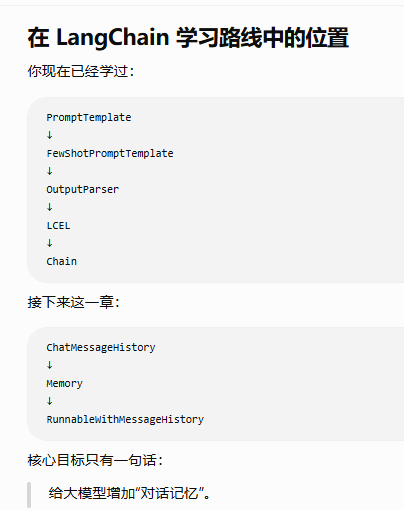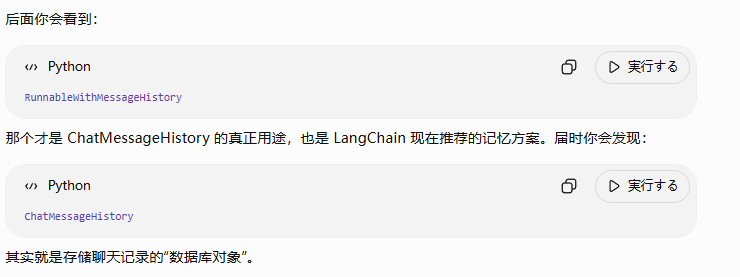

场景2：对接LLM



In [3]:
# 1、获取大模型
import os
import dotenv
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

In [5]:
from langchain.memory import ChatMessageHistory

# 1、ChatMessageHistory的实例化

history = ChatMessageHistory()

# 2、添加相关的消息进行存储
history.add_user_message("你好")
history.add_ai_message("很高兴认识你")
history.add_user_message("帮我计算1 + 2 * 3 = ？")

response = llm.invoke(history.messages)
#print(response.content)
print("===== 发送给模型的消息 =====")

for i, msg in enumerate(history.messages, start=1):
    print(f"\n第{i}条")
    print("类型:", type(msg).__name__)
    print("内容:", msg.content)

===== 发送给模型的消息 =====

第1条
类型: HumanMessage
内容: 你好

第2条
类型: AIMessage
内容: 很高兴认识你

第3条
类型: HumanMessage
内容: 帮我计算1 + 2 * 3 = ？


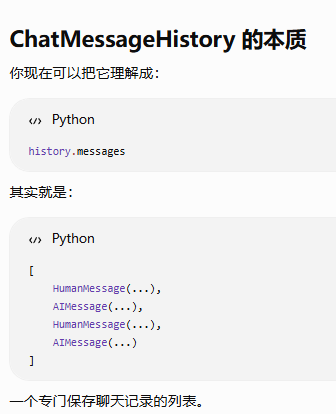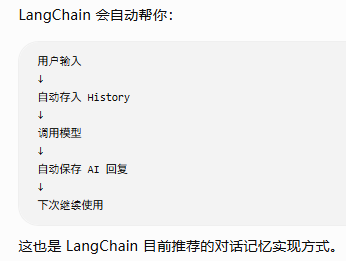

# 2、ConversationBufferMemory的使用   旧方案

举例1：以字符串的方式返回存储的信息

In [7]:
from langchain.memory import ConversationBufferMemory

# 1、ConversationBufferMemory的实例化
memory = ConversationBufferMemory()

# 2、存储相关的消息
# inputs对应的就是用户消息，outputs对应的就是ai消息
memory.save_context(inputs={"human": "你好，我叫小明"}, outputs={"ai": "很高兴认识你"})
memory.save_context(inputs={"input": "帮我回答一下1+2*3=?"}, outputs={"output": "7"})

# 3、获取存储的信息
#print(memory.load_memory_variables({}))

#说明：返回的字典结构的key叫history.

result = memory.load_memory_variables({})
print("===== 返回类型 =====")
print(type(result))

print("\n===== 所有Key =====")
print(result.keys())

print("\n===== History内容 =====")
print(result["history"])

===== 返回类型 =====
<class 'dict'>

===== 所有Key =====
dict_keys(['history'])

===== History内容 =====
{'human': '你好，我叫小明'}
{'ai': '很高兴认识你'}
{'input': '帮我回答一下1+2*3=?'}
{'output': '7'}


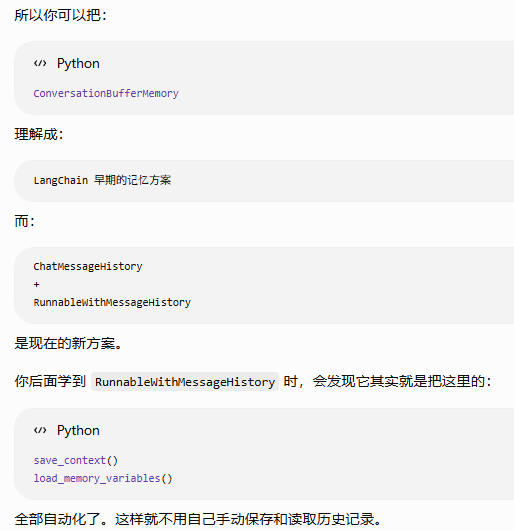

举例2：以消息列表的方式返回存储的信息

In [9]:
from langchain.memory import ConversationBufferMemory

# 1、ConversationBufferMemory的实例化
memory = ConversationBufferMemory(return_messages=True)

# 2、存储相关的消息
# inputs对应的就是用户消息，outputs对应的就是ai消息
memory.save_context(inputs={"human": "你好，我叫小明"}, outputs={"ai": "很高兴认识你"})
memory.save_context(inputs={"input": "帮我回答一下1+2*3=?"}, outputs={"output": "7"})

# 3、获取存储的信息
#返回消息列表的方式1：
#print(memory.load_memory_variables({}))

#print("\n")

#返回消息列表的方式2：
#print(memory.chat_memory.messages)

#说明：返回的字典结构的key叫history.
result = memory.load_memory_variables({})

print("===== 返回类型 =====")
print(type(result))

print("\n===== history类型 =====")
print(type(result["history"]))

print("\n===== 消息列表 =====")

for i, msg in enumerate(result["history"], start=1):
    print(f"\n第{i}条")
    print("类型:", type(msg).__name__)
    print("内容:", msg.content)

===== 返回类型 =====
<class 'dict'>

===== history类型 =====
<class 'list'>

===== 消息列表 =====

第1条
类型: HumanMessage
内容: {'human': '你好，我叫小明'}

第2条
类型: AIMessage
内容: {'ai': '很高兴认识你'}

第3条
类型: HumanMessage
内容: {'input': '帮我回答一下1+2*3=?'}

第4条
类型: AIMessage
内容: {'output': '7'}


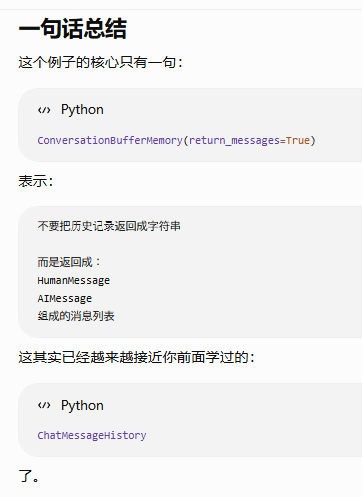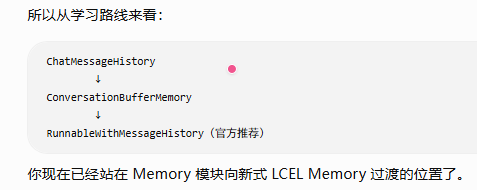

举例3：结合大模型、提示词模板的使用（PromptTemplate）

In [10]:
from langchain.chains.llm import LLMChain
from langchain_openai import ChatOpenAI
from langchain_core.prompts.prompt import PromptTemplate

# 1、创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 2、提供提示词模板
prompt_template = PromptTemplate.from_template(
    template="""
    你可以与人类对话。

当前对话历史: {history}

人类问题: {question}

回复:
"""
)

# 3、提供memory实例
memory = ConversationBufferMemory()

# 4、提供Chain
chain = LLMChain(llm=llm, prompt=prompt_template, memory=memory)

response = chain.invoke({"question": "你好，我的名字叫小明"})
print(response)

{'text': '你好，小明。我是一个AI助手，可以回答各种问题，提供信息，以及帮助解答关于日常生活问题。有什么我可以帮助你的吗？', 'output': '你好，小明。我是一个AI助手，可以回答各种问题，提供信息，以及帮助解答关于日常生活问题。有什么我可以帮助你的吗？'}


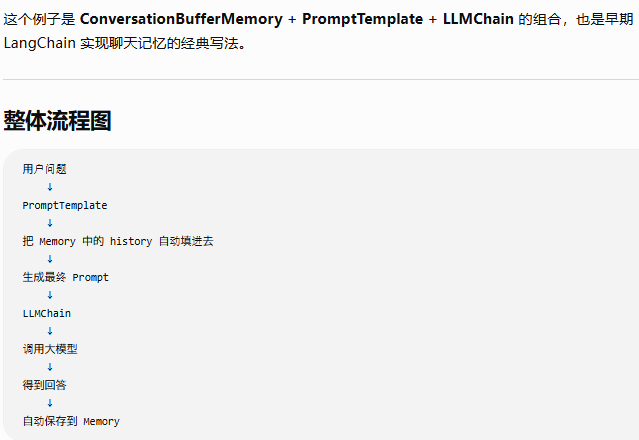

In [11]:
response = chain.invoke({"question": "我叫什么名字呢？"})
print(response)

{'text': '你是小明', 'output': '你是小明'}


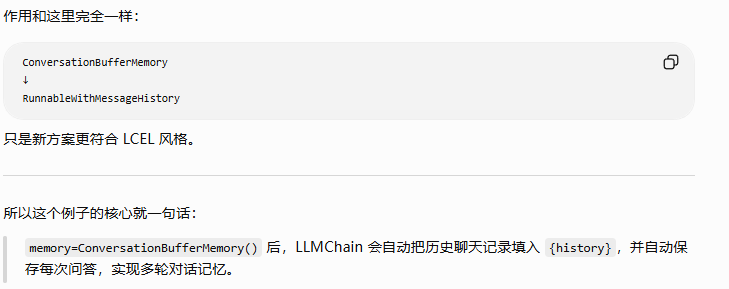

举例4：基于举例3，显式的设置meory的key的值


In [14]:
from langchain.chains.llm import LLMChain
from langchain_openai import ChatOpenAI
from langchain_core.prompts.prompt import PromptTemplate

# 1、创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 2、提供提示词模板
prompt_template = PromptTemplate.from_template(
    template="""
    你可以与人类对话。

当前对话历史: {chat_history}

人类问题: {question}

回复:
"""
)

# 3、提供memory实例
memory = ConversationBufferMemory(memory_key="chat_history")

# 4、提供Chain
chain = LLMChain(llm=llm, prompt=prompt_template, memory=memory)

response = chain.invoke({"question": "你好，我的名字叫小明"})
print(response)

print("===== Memory内容 =====")
print(memory.load_memory_variables({}))

{'text': '你好，小明！有什么我可以帮你的吗？', 'output': '你好，小明！有什么我可以帮你的吗？'}
===== Memory内容 =====
{'chat_history': "{'question': '你好，我的名字叫小明'}\n{'output': '你好，小明！有什么我可以帮你的吗？'}"}


In [13]:
response = chain.invoke({"question": "我叫什么名字呢？"})
print(response)

{'text': '你是小明', 'output': '你是小明'}


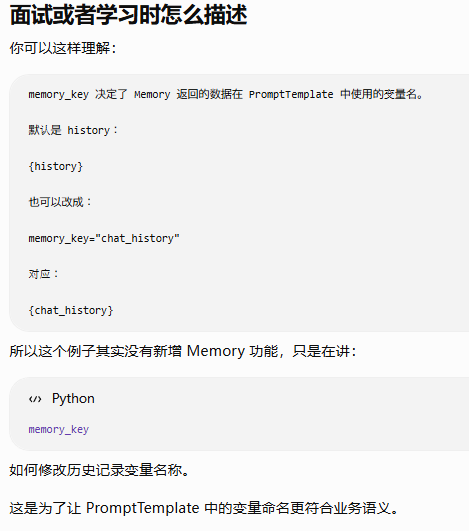

举例5：结合大模型、提示词模板的使用（ChatPromptTemplate）

In [17]:
# 1.导入相关包
from langchain_core.messages import SystemMessage
from langchain.chains.llm import LLMChain
from langchain.memory import ConversationBufferMemory
from langchain_core.prompts import MessagesPlaceholder,ChatPromptTemplate,HumanMessagePromptTemplate
from langchain_openai import ChatOpenAI


# 2.创建LLM
llm = ChatOpenAI(model_name='qwen2.5-coder:1.5b')

# 3.创建Prompt
prompt = ChatPromptTemplate.from_messages([
    ("system","你是一个与人类对话的机器人。"),
    MessagesPlaceholder(variable_name='history'),
    ("human","问题：{question}")
])

# 4.创建Memory
memory = ConversationBufferMemory(return_messages=True)
# 5.创建LLMChain
llm_chain = LLMChain(prompt=prompt,llm=llm, memory=memory)

# 6.调用LLMChain
res1 = llm_chain.invoke({"question": "中国首都在哪里？"})
print(res1,end="\n\n")

print("===== Memory内容 =====")

for i,msg in enumerate(memory.chat_memory.messages,1):

    print(f"\n第{i}条消息")
    print("类型:",type(msg).__name__)
    print("内容:",msg.content)



{'text': '中国首都在 Beijing。', 'output': '中国首都在 Beijing。'}

===== Memory内容 =====

第1条消息
类型: HumanMessage
内容: {'question': '中国首都在哪里？'}

第2条消息
类型: AIMessage
内容: {'output': '中国首都在 Beijing。'}


In [16]:
res2 = llm_chain.invoke({"question": "我刚刚问了什么"})
print(res2)


{'text': "{'output': '你刚刚问的是中国首都在哪里。'}", 'output': "{'output': '你刚刚问的是中国首都在哪里。'}"}


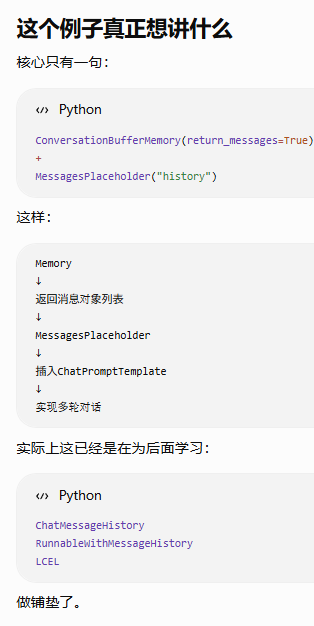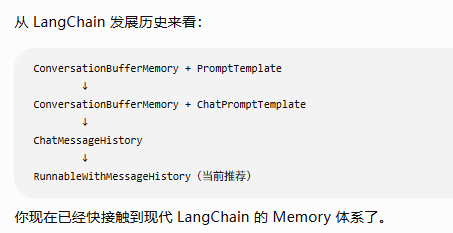

# 3、ConversationChain的使用

举例1：以PromptTemplate为例

In [18]:
from langchain.chains.conversation.base import ConversationChain
from langchain.chains.llm import LLMChain
from langchain_openai import ChatOpenAI
from langchain_core.prompts.prompt import PromptTemplate

# 1、创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 2、提供提示词模板
prompt_template = PromptTemplate.from_template(
    template="""
    你可以与人类对话。

当前对话历史: {history}

人类问题: {input}

回复:
"""
)

# # 3、提供memory实例
# memory = ConversationBufferMemory()
#
# # 4、提供Chain
# chain = LLMChain(llm=llm, prompt=prompt_template, memory=memory)

# 3、创建ConversationChain的实例
chain = ConversationChain(llm = llm, prompt=prompt_template)

response = chain.invoke({"input": "你好，我的名字叫小明"})
print(response)

AIMessage(content='你好，小明！很高兴你能加入我们的对话，你想聊些什么吗？', additional_kwargs={})


In [19]:
response = chain.invoke({"input": "我的名字叫什么？"})
print(response)

AIMessage(content='你的名字叫小明。', additional_kwargs={})


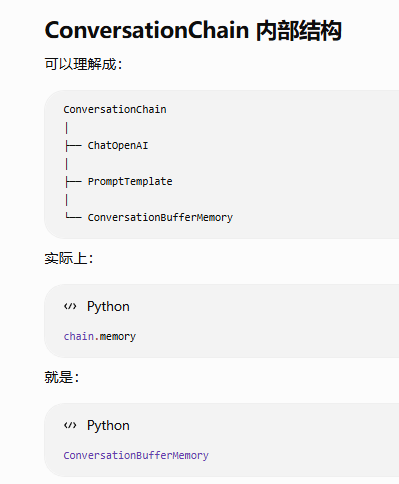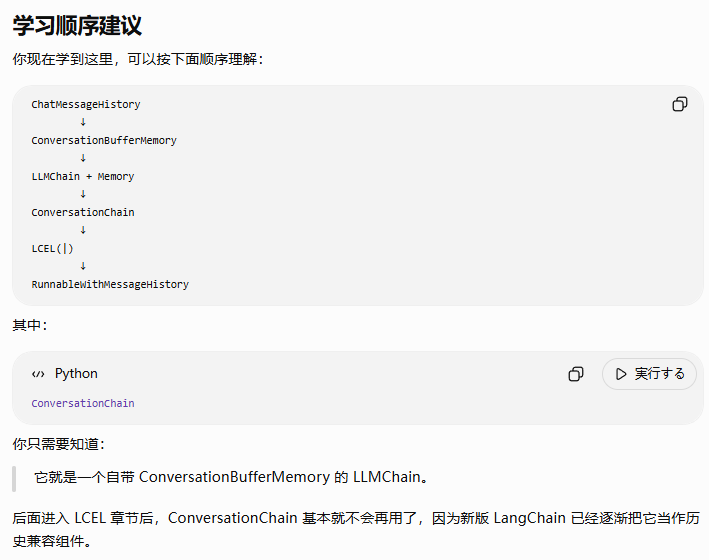

举例2：使用默认提供的提示词模板



In [20]:
from langchain.chains.conversation.base import ConversationChain
from langchain.chains.llm import LLMChain
from langchain_openai import ChatOpenAI
from langchain_core.prompts.prompt import PromptTemplate

# 1、创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 2、提供提示词模板
# prompt_template = PromptTemplate.from_template(
#     template="""
#     你可以与人类对话。
#
# 当前对话历史: {history}
#
# 人类问题: {input}
#
# 回复:
# """
# )

# # 3、提供memory实例
# memory = ConversationBufferMemory()
#
# # 4、提供Chain
# chain = LLMChain(llm=llm, prompt=prompt_template, memory=memory)

# 3、创建ConversationChain的实例（内部提供了默认的提示词模板。而此模板中的变量是{input}、{history}
chain = ConversationChain(llm = llm)

response = chain.invoke({"input": "你好，我的名字叫小明"})
print(response)

AIMessage(content='你好！很高兴认识你。你可以问我任何问题，无论是学习问题、兴趣问题还是日常问题，我都会尽力帮助你。有什么我可以帮忙的吗？', additional_kwargs={})


In [21]:
response = chain.invoke({"input": "我的名字叫什么？"})
print(response)

AIMessage(content='请问，您的名字叫什么？', additional_kwargs={})


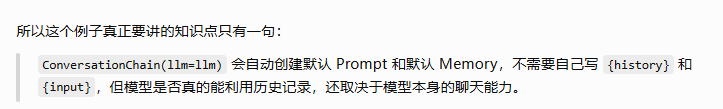

# 4、ConversationBufferWindowMemory的使用

举例1：ConversationBufferWindowMemory（窗口记忆），它是 ConversationBufferMemory 的升级版。


In [22]:
# 1.导入相关包
from langchain.memory import ConversationBufferWindowMemory

# 2.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=1)
# 3.保存消息
memory.save_context({"input": "你好"}, {"output": "怎么了"})
memory.save_context({"input": "你是谁"}, {"output": "我是AI助手"})
memory.save_context({"input": "你的生日是哪天？"}, {"output": "我不清楚"})
# 4.读取内存中消息（返回消息内容的纯文本）
print(memory.load_memory_variables({}))

{'history': "{'output': '我不清楚'}"}


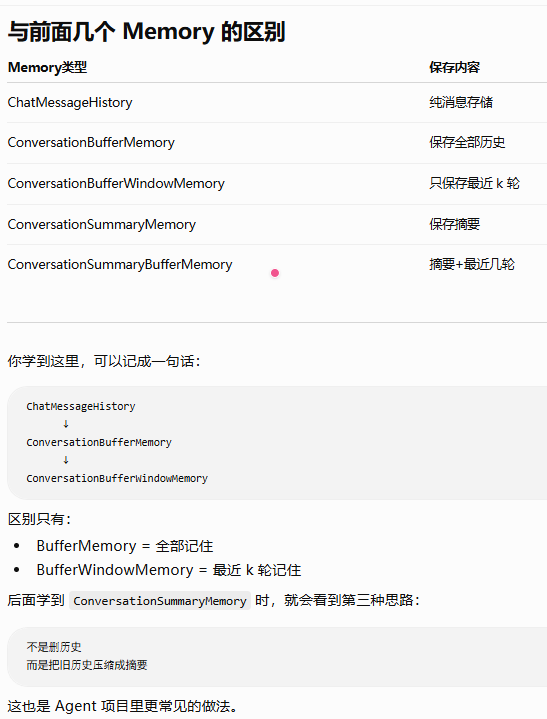

举例2：返回消息构成的上下文记忆


In [25]:
# 1.导入相关包
from langchain.memory import ConversationBufferWindowMemory

# 2.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=2, return_messages=True)
# 3.保存消息
memory.save_context({"input": "你好"}, {"output": "怎么了"})
memory.save_context({"input": "你是谁"}, {"output": "我是AI助手小智"})
memory.save_context({"input": "初次对话，你能介绍一下你自己吗？"}, {"output": "当然可以了。我是一个无所不能的小智。"})
# 4.读取内存中消息（返回消息内容的纯文本）
print(memory.load_memory_variables({}))

history = memory.load_memory_variables({})
print("===== history =====")
print(type(history["history"]))

for msg in history["history"]:
    print(type(msg))
    print(msg.content)

{'history': [HumanMessage(content="{'input': '初次对话，你能介绍一下你自己吗？'}", additional_kwargs={}), AIMessage(content="{'output': '当然可以了。我是一个无所不能的小智。'}", additional_kwargs={})]}
===== history =====
<class 'list'>
<class 'langchain_core.HumanMessage'>
{'input': '初次对话，你能介绍一下你自己吗？'}
<class 'langchain_core.AIMessage'>
{'output': '当然可以了。我是一个无所不能的小智。'}


举例3：结合llm、chain的使用


In [26]:
from langchain.memory import ConversationBufferWindowMemory
# 1.导入相关包
from langchain_core.prompts.prompt import PromptTemplate
from langchain.chains.llm import LLMChain

# 2.定义模版
template = """以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。

当前对话：
{history}
Human: {question}
AI:"""

# 3.定义提示词模版
prompt_template = PromptTemplate.from_template(template)

# 4.创建大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 5.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=1)

# 6.定义LLMChain
conversation_with_summary = LLMChain(
    llm=llm,
    prompt=prompt_template,
    memory=memory,
    #verbose=True,
)

# 7.执行链（第一次提问）
respon1 = conversation_with_summary.invoke({"question":"你好，我是孙小空"})
print(respon1)
# 8.执行链（第二次提问）
respon2 =conversation_with_summary.invoke({"question":"我还有两个师弟，一个是猪小戒，一个是沙小僧"})
print(respon2)
# 9.执行链（第三次提问）
respon3 =conversation_with_summary.invoke({"question":"我今年高考，竟然考上了1本"})
print(respon3)
# 10.执行链（第四次提问）
respon4 =conversation_with_summary.invoke({"question":"我叫什么名字？"})
print(respon4)

{'text': '你好，孙小空，我是小帮手，有什么我可以帮忙的吗？', 'output': '你好，孙小空，我是小帮手，有什么我可以帮忙的吗？'}
{'text': '你好，孙小空，我了解了猪小戒和沙小僧。我有一个共同的名字，我们可以叫小猪小戒和小沙沙小僧。有什么我可以帮忙的吗？', 'output': '你好，孙小空，我了解了猪小戒和沙小僧。我有一个共同的名字，我们可以叫小猪小戒和小沙沙小僧。有什么我可以帮忙的吗？'}
{'text': '那真是太棒了！高考是一个非常重要的阶段，能够有好的成绩说明你对学习和自己的努力有着极大的热情和信心。如果还有其他问题或需要帮助的地方，随时欢迎随时问。祝你在你的学习和发展道路上再创佳绩！有什么特别想问的吗？', 'output': '那真是太棒了！高考是一个非常重要的阶段，能够有好的成绩说明你对学习和自己的努力有着极大的热情和信心。如果还有其他问题或需要帮助的地方，随时欢迎随时问。祝你在你的学习和发展道路上再创佳绩！有什么特别想问的吗？'}
{'text': '你好！我是AI助手，我的名字是Qwen。', 'output': '你好！我是AI助手，我的名字是Qwen。'}


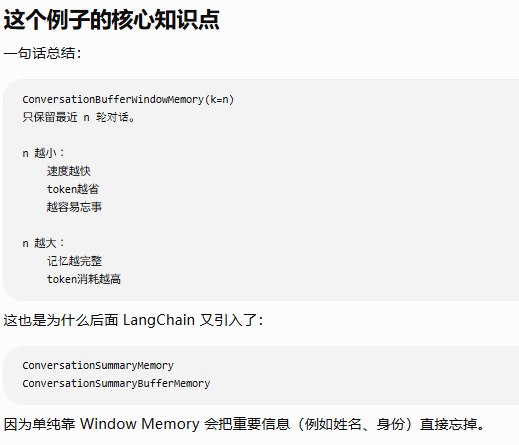

举例4：修改举例3中的参数k


In [29]:
from langchain.memory import ConversationBufferWindowMemory
# 1.导入相关包
from langchain_core.prompts.prompt import PromptTemplate
from langchain.chains.llm import LLMChain

# 2.定义模版
template = """以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。

当前对话：
{history}
Human: {question}
AI:"""

# 3.定义提示词模版
prompt_template = PromptTemplate.from_template(template)

# 4.创建大模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 5.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=3)

# 6.定义LLMChain
conversation_with_summary = LLMChain(
    llm=llm,
    prompt=prompt_template,
    memory=memory,
    #verbose=True,
)

# 7.执行链（第一次提问）
respon1 = conversation_with_summary.invoke({"question":"你好，我是孙小空"})
# print(respon1)
# 8.执行链（第二次提问）
respon2 =conversation_with_summary.invoke({"question":"我还有两个师弟，一个是猪小戒，一个是沙小僧"})
# print(respon2)
# 9.执行链（第三次提问）
respon3 =conversation_with_summary.invoke({"question":"我今年高考，竟然考上了1本"})
# print(respon3)
# 10.执行链（第四次提问）
respon4 =conversation_with_summary.invoke({"question":"我叫什么名字？"})
print(respon4)

{'text': '你好！你的名字叫孙小空。有什么我可以帮助你的吗？', 'output': '你好！你的名字叫孙小空。有什么我可以帮助你的吗？'}


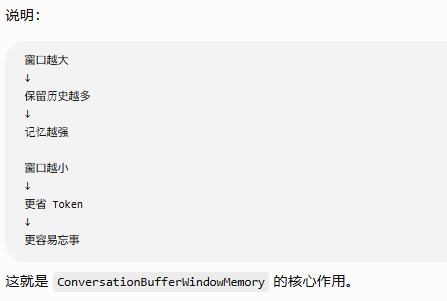